# 06. Comparison Report

This notebook assembles the final project comparison from the cleaned artifacts and the rebuilt analyses. It separates directly comparable results from exploratory ones so the final ranking is honest about scope.

**Executive summary**
- LightGBM is the strongest practical model in the current project.
- Classical models are useful baselines but not close to the best ML result.
- Deep-learning and ensemble sections are informative, but their scope differs from the main ML run.
- The project does not currently include calibrated prediction intervals, quantile forecasts, or interval metrics.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

DATA_DIR = Path('../data/ts-forecasting')
PROCESSED_DIR = Path('../data/processed')
VAL_CUTOFF = 2880

def weighted_skill(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight * (y_true ** 2))
    if denom == 0:
        return np.nan
    ratio = np.sum(weight * ((y_true - y_pred) ** 2)) / denom
    ratio = min(max(ratio, 0.0), 1.0)
    return float(np.sqrt(1.0 - ratio))

def weighted_rmse(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sqrt(np.sum(weight * ((y_true - y_pred) ** 2)) / denom))

def weighted_mae(y_true, y_pred, weight):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    weight = np.asarray(weight, dtype=float)
    denom = np.sum(weight)
    if denom == 0:
        return np.nan
    return float(np.sum(weight * np.abs(y_true - y_pred)) / denom)

classical = pd.read_parquet(PROCESSED_DIR / 'classical_val_results.parquet')
ml = pd.read_parquet(PROCESSED_DIR / 'ml_val_preds.parquet')
dl = pd.read_parquet(PROCESSED_DIR / 'dl_val_preds.parquet')
dl_summary = pd.read_parquet(PROCESSED_DIR / 'dl_results_summary.parquet')
ensemble = pd.read_parquet(PROCESSED_DIR / 'ensemble_results.parquet')


## Build a comparison table

We combine one representative classical score summary, the row-level ML metrics, the saved deep-learning summary, and the saved ensemble methods.


In [2]:
classical_best = (
    classical.groupby('model')['skill_score']
             .mean()
             .sort_values(ascending=False)
             .reset_index()
             .rename(columns={'model': 'Model', 'skill_score': 'Skill Score'})
)
classical_best['Family'] = 'Classical'

ml_table = pd.DataFrame([
    {'Model': 'LightGBM', 'Skill Score': weighted_skill(ml['y_true'], ml['lgb_pred'], ml['weight']), 'Family': 'ML (global)'},
    {'Model': 'XGBoost', 'Skill Score': weighted_skill(ml['y_true'], ml['xgb_pred'], ml['weight']), 'Family': 'ML (global)'},
])

dl_table = dl_summary[['Model', 'Skill Score']].copy()
dl_table['Family'] = 'Deep learning (sampled)'

ensemble_table = ensemble[['Method', 'Skill Score']].rename(columns={'Method': 'Model'}).copy()
ensemble_table['Family'] = 'Ensemble / hybrid'

comparison = pd.concat([
    classical_best.head(5),
    ml_table,
    dl_table,
    ensemble_table,
], ignore_index=True)
comparison = comparison.sort_values('Skill Score', ascending=False).reset_index(drop=True)
comparison


,Model,Skill Score,Family
0,Per-Series Selection,0.996302,Ensemble / hybrid
1,LightGBM,0.996302,Ensemble / hybrid
2,LightGBM,0.996302,ML (global)
3,Stacking (Ridge),0.992193,Ensemble / hybrid
4,Cascade (0.1×Zero + 0.9×LGB),0.991198,Ensemble / hybrid
5,Inv-Error Weighted,0.390080,Ensemble / hybrid
6,Expanding Mean,0.262644,Classical
7,Naive,0.144422,Classical
8,ARIMA,0.132925,Classical
9,ETS,0.110362,Classical


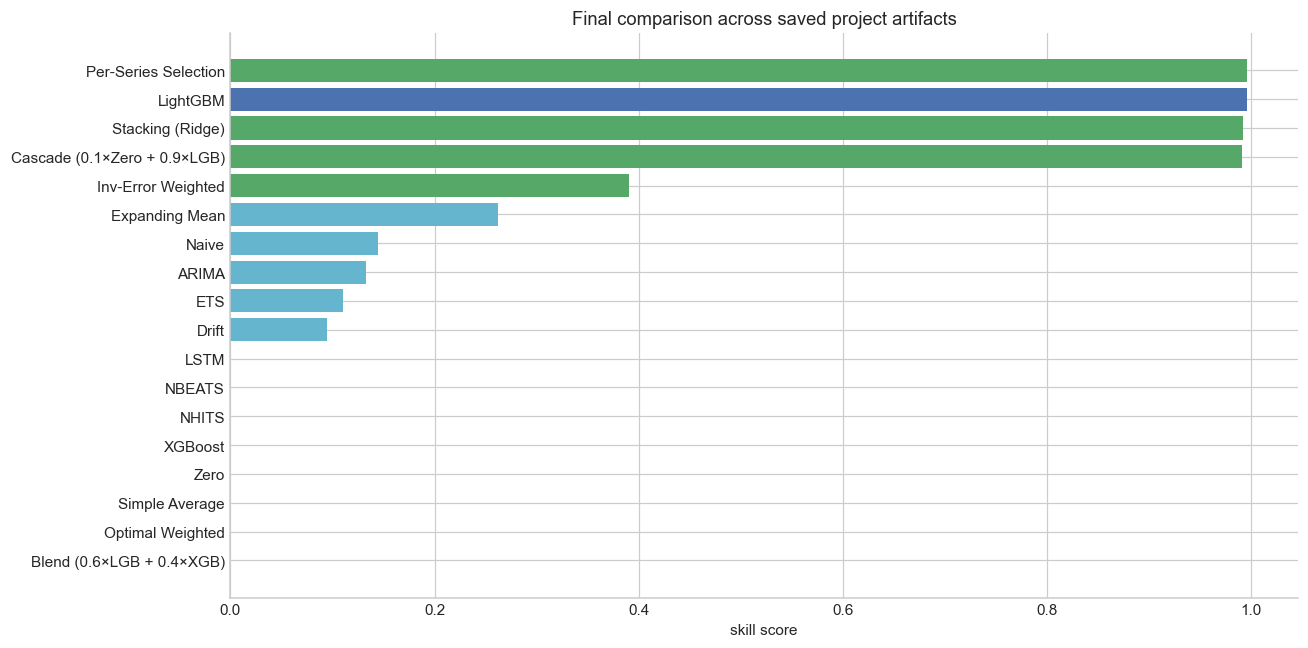

In [3]:
fig, ax = plt.subplots(figsize=(12, 6))
colors = comparison['Family'].map({
    'Classical': '#64B5CD',
    'ML (global)': '#4C72B0',
    'Deep learning (sampled)': '#8172B3',
    'Ensemble / hybrid': '#55A868',
})
ax.barh(comparison['Model'], comparison['Skill Score'], color=colors)
ax.invert_yaxis()
ax.set_title('Final comparison across saved project artifacts')
ax.set_xlabel('skill score')
plt.tight_layout()
plt.show()


## Horizon view for the directly comparable ML models

The cleanest pairwise horizon comparison in the project is still LightGBM versus XGBoost, because those models share the same validation rows.


In [4]:
rows = []
for horizon_value, grp in ml.groupby('horizon'):
    rows.append({
        'horizon': horizon_value,
        'LightGBM': weighted_skill(grp['y_true'], grp['lgb_pred'], grp['weight']),
        'XGBoost': weighted_skill(grp['y_true'], grp['xgb_pred'], grp['weight']),
    })
ml_horizon = pd.DataFrame(rows).sort_values('horizon')
ml_horizon


,horizon,LightGBM,XGBoost
0,1,0.993182,0.0
1,3,0.995396,0.0
2,10,0.996428,0.0
3,25,0.996797,0.0


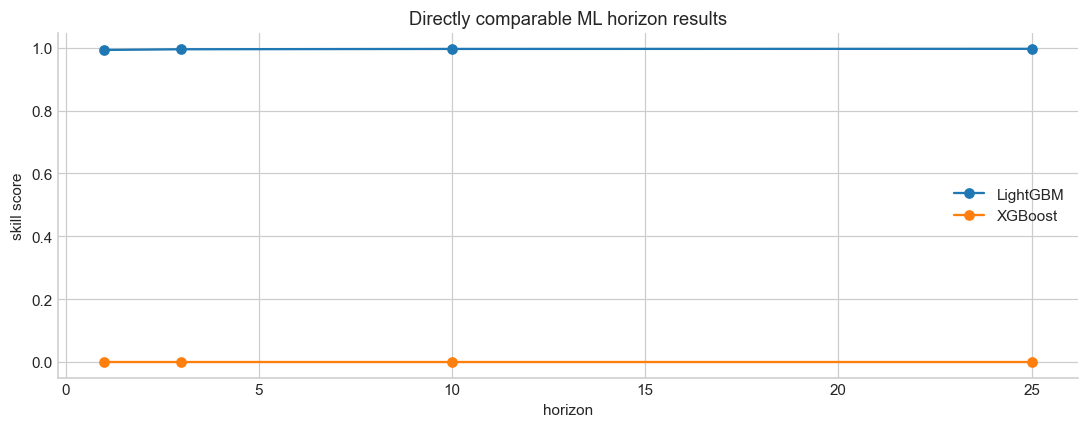

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ml_horizon['horizon'], ml_horizon['LightGBM'], marker='o', label='LightGBM')
ax.plot(ml_horizon['horizon'], ml_horizon['XGBoost'], marker='o', label='XGBoost')
ax.set_title('Directly comparable ML horizon results')
ax.set_xlabel('horizon')
ax.set_ylabel('skill score')
ax.legend()
plt.tight_layout()
plt.show()


## Scope and honesty check

The report is strongest when it separates what is directly comparable from what is exploratory. This section makes that explicit.


In [6]:
scope_table = pd.DataFrame([
    {'section': 'Classical models', 'comparison_scope': 'point forecasts on saved per-series validation results'},
    {'section': 'ML models', 'comparison_scope': 'directly comparable row-level validation predictions'},
    {'section': 'Deep learning', 'comparison_scope': 'sampled experiment with point predictions only'},
    {'section': 'Ensembles', 'comparison_scope': 'mix of saved methods and exploratory validation-derived combinations'},
])
scope_table


,section,comparison_scope
0,Classical models,point forecasts on saved per-series validation...
1,ML models,directly comparable row-level validation predi...
2,Deep learning,sampled experiment with point predictions only
3,Ensembles,mix of saved methods and exploratory validatio...


## Probabilistic forecasting gap

Because you explicitly asked about interval bands and metrics, we check the available artifact schemas rather than guessing.


In [7]:
artifact_columns = {
    'ml_val_preds': list(ml.columns),
    'dl_val_preds': list(dl.columns),
    'ensemble_results': list(ensemble.columns),
}
interval_tokens = ['lower', 'upper', 'quant', 'q10', 'q50', 'q90', 'pi', 'interval']
interval_findings = {
    name: [c for c in cols if any(tok in c.lower() for tok in interval_tokens)]
    for name, cols in artifact_columns.items()
}
print('Interval-like columns by artifact:')
for name, cols in interval_findings.items():
    print(name, cols)


Interval-like columns by artifact:
ml_val_preds []
dl_val_preds []
ensemble_results []


## Final takeaway

- The strongest practical model in this project is LightGBM.
- Classical models remain valuable for baseline context, but they do not challenge the global ML result.
- The deep-learning and ensemble notebooks still add insight, but their scopes are narrower or more exploratory than the main ML comparison.
- The project is currently deterministic. If you later want the interval “tube” charts and metrics such as `PICP` or `MPIW`, that needs a separate probabilistic forecasting layer rather than a plotting-only change.
